In [1]:
import tensorflow as tf

url = "https://huggingface.co/iamsanjayashok/flw/resolve/main/flowers.zip"

zip_path = tf.keras.utils.get_file(
    fname="flowers.zip",
    origin=url,
    extract=True
)

print(zip_path)

241331624/241331624 ━━━━━━━━━━━━━━━━━━━━ 12s 0us/step
C:\Users\Sanjay A\.keras\datasets\flowers_extracted


In [6]:
base_path = r"C:\Users\Sanjay A\.keras\datasets\flowers_extracted\flowers (1)"

['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']
Total images loaded: 4331
95/95 ━━━━━━━━━━━━━━━━━━━━ 581s 6s/step - accuracy: 0.2484 - loss: 2.1714 - val_accuracy: 0.3192 - val_loss: 1.5554
136/136 ━━━━━━━━━━━━━━━━━━━━ 226s 2s/step - accuracy: 0.3281 - loss: 1.5525
Loss: 1.552544355392456
Accuracy: 0.3280997574329376
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 841ms/step


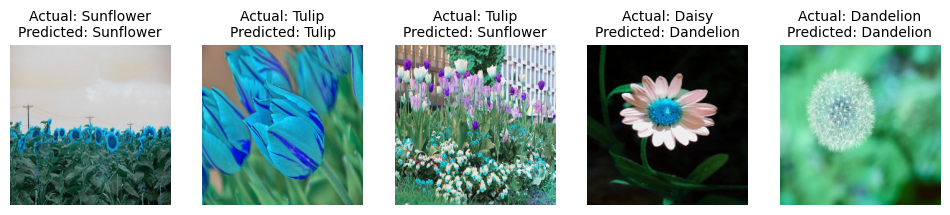

In [8]:
import numpy as np
import pandas as pd
import os
import glob
import cv2
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense

print(os.listdir(base_path))

folders = glob.glob(base_path + "/*")

imagenames_list = []
for folder in folders:
    for f in glob.glob(folder + '/*.jpg'):
        imagenames_list.append(f)


def label_img(image):
    word_label = os.path.basename(os.path.dirname(image))
    if word_label == 'daisy':
        return [1,0,0,0,0]
    elif word_label == 'dandelion':
        return [0,1,0,0,0]
    elif word_label == 'rose':
        return [0,0,1,0,0]
    elif word_label == 'tulip':
        return [0,0,0,1,0]
    else:
        return [0,0,0,0,1]

train = []
for image in imagenames_list:
    img = cv2.imread(image)

    if img is None:
        continue

    img = cv2.resize(img, (224,224))
    label = label_img(image)

    train.append([np.array(img), np.array(label)])

np.random.shuffle(train)


print("Total images loaded:", len(train))

X = np.array([i[0] for i in train])
X = X / 255.0
Y = np.array([i[1] for i in train])


model = Sequential()
model.add(VGG16(include_top=False, weights='imagenet', input_shape=(224,224,3)))
model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dense(5, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='sgd', metrics=['accuracy'])


Fit = model.fit(X, Y, epochs=1, validation_split=0.30)

loss, accuracy = model.evaluate(X, Y)
print(f"Loss: {loss}")
print(f"Accuracy: {accuracy}")

import matplotlib.pyplot as plt

num_images = 5
random_indices = np.random.choice(len(X), num_images, replace=False)

selected_images = X[random_indices]
true_labels = Y[random_indices]

predictions = model.predict(selected_images)
predicted_classes = np.argmax(predictions, axis=1)

flower_names = ['Daisy', 'Dandelion', 'Rose', 'Tulip', 'Sunflower']

plt.figure(figsize=(12,6))
for i in range(num_images):
    plt.subplot(1, num_images, i+1)
    plt.imshow(selected_images[i])
    plt.axis('off')

    actual = flower_names[np.argmax(true_labels[i])]
    predicted = flower_names[predicted_classes[i]]

    plt.title(f"Actual: {actual}\nPredicted: {predicted}", fontsize=10)

plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator

base_path = r"C:\Users\Sanjay A\.keras\datasets\flowers_extracted\flowers (1)"

datagen = ImageDataGenerator( 
    rescale=1./255,
    validation_split=0.3
)

train_generator = datagen.flow_from_directory(
    base_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

validation_generator = datagen.flow_from_directory(
    base_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)


model = Sequential([
    VGG16(include_top=False,weights='imagenet',input_shape=(128,128,3),trainable = False),
    Flatten(),
    Dense(256, activation='relu'),
    Dense(5, activation='softmax')])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit( train_generator,validation_data=validation_generator,epochs=1)

loss, accuracy = model.evaluate(validation_generator)

print("Loss:", loss)
print("Accuracy:", accuracy)

# Prediction on random images
images, labels = next(validation_generator)

predictions = model.predict(images)

flower_names = ['Daisy', 'Dandelion', 'Rose', 'Sunflower', 'Tulip']

plt.figure(figsize=(15,5))

for i in range(5):

    plt.subplot(1,5,i+1)

    plt.imshow(images[i])

    actual = flower_names[np.argmax(labels[i])]
    predicted = flower_names[np.argmax(predictions[i])]

    plt.title(f"A:{actual}\nP:{predicted}")
    plt.axis('off')

plt.show()

Found 3033 images belonging to 5 classes.
Found 1298 images belonging to 5 classes.
70/95 ━━━━━━━━━━━━━━━━━━━━ 13s 556ms/step - accuracy: 0.5008 - loss: 1.5479